In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import cv2
import scipy.ndimage as nd
from skimage.morphology import skeletonize
import os
import json
import glob
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# --- 1. Differentiable Canvas V4: Line + Circle Primitives ---
class DifferentiableCanvasV4(nn.Module):
    """
    Renders two primitive types in a single batched forward pass:
      - Line strokes : params [x1, y1, x2, y2, thickness, opacity]  (type_flag < 0.5)
      - Circle rings : params [cx, cy, radius, thickness, opacity, _] (type_flag >= 0.5)
    stroke_params shape: [N, 7]  (6 geometry params + 1 type_flag)
    """
    def __init__(self, canvas_size=128):
        super().__init__()
        self.canvas_size = canvas_size
        y, x = torch.meshgrid(
            torch.linspace(0, 1, canvas_size, device=device),
            torch.linspace(0, 1, canvas_size, device=device),
            indexing="ij"
        )
        self.register_buffer("grid_x", x)
        self.register_buffer("grid_y", y)

    def forward(self, stroke_params, global_blur):
        """
        stroke_params: [N, 7] float tensor, all values in [0,1] after sigmoid.
        global_blur:   scalar float, annealed from start_blur -> end_blur.
        Returns: [H, W] canvas, 1.0=white background, 0.0=ink.
        """
        stroke_params = torch.as_tensor(stroke_params,
                                        device=self.grid_x.device,
                                        dtype=torch.float32)
        N = stroke_params.shape[0]
        gx = self.grid_x.unsqueeze(0)   # [1, H, W]
        gy = self.grid_y.unsqueeze(0)

        p = stroke_params                # [N, 7]
        type_flag = p[:, 6].view(N, 1, 1)   # soft type: <0.5=line, >=0.5=circle

        # ---- Line primitive ------------------------------------------------
        x1 = p[:, 0].view(N, 1, 1);  y1 = p[:, 1].view(N, 1, 1)
        x2 = p[:, 2].view(N, 1, 1);  y2 = p[:, 3].view(N, 1, 1)
        th_l = p[:, 4].view(N, 1, 1); op_l = p[:, 5].view(N, 1, 1)

        ax, ay   = x2 - x1, y2 - y1
        mag_sq   = ax**2 + ay**2 + 1e-6
        t        = torch.clamp(((gx - x1)*ax + (gy - y1)*ay) / mag_sq, 0., 1.)
        line_dist_sq = (gx - (x1 + t*ax))**2 + (gy - (y1 + t*ay))**2
        sigma_l  = (th_l**2) * 0.015 + global_blur
        # Use squared thickness so thin strokes can get very sharp
        line_ink = op_l * torch.exp(-line_dist_sq / (2 * sigma_l**2))   # [N,H,W]

        # ---- Circle primitive ----------------------------------------------
        # Reuse first 5 params: [cx, cy, radius, thickness, opacity]
        cx = p[:, 0].view(N, 1, 1);  cy = p[:, 1].view(N, 1, 1)
        r  = p[:, 2].view(N, 1, 1) * 0.5   # max radius = 0.5 (half canvas)
        th_c = p[:, 3].view(N, 1, 1); op_c = p[:, 4].view(N, 1, 1)

        dist_from_center = torch.sqrt((gx - cx)**2 + (gy - cy)**2 + 1e-6)
        ring_dist_sq     = (dist_from_center - r)**2
        sigma_c          = (th_c**2) * 0.015 + global_blur
        circ_ink = op_c * torch.exp(-ring_dist_sq / (2 * sigma_c**2))   # [N,H,W]

        # ---- Soft blend by type_flag (differentiable switch) ---------------
        # type_flag=0 -> pure line, type_flag=1 -> pure circle
        ink = (1.0 - type_flag) * line_ink + type_flag * circ_ink       # [N,H,W]

        combined = ink.sum(dim=0)                                        # [H,W]
        return torch.clamp(1.0 - combined, 0., 1.)

In [3]:
# --- 2. Dynamic Heuristics Analyzer ---
def analyze_image_heuristics(img_array):
    """
    Uses skeleton pixel count (not raw Canny edges) for accurate stroke estimation.
    Also detects circular blobs to hint at circle primitive usage.
    """
    img_8u   = (img_array * 255).astype(np.uint8)
    inverted = cv2.bitwise_not(img_8u)

    # Skeleton gives a 1-pixel-wide structural backbone
    ink_binary = inverted > 127
    skeleton   = skeletonize(ink_binary)
    skel_pixels = np.sum(skeleton)

    # Each stroke covers ~15 skeleton pixels on a 128px canvas
    estimated_strokes = int((skel_pixels / 15) * 1.3)
    num_strokes = max(8, min(estimated_strokes, 120))

    # Detect blobs (circles) using HoughCircles to hint type_flag init
    circles = cv2.HoughCircles(
        inverted, cv2.HOUGH_GRADIENT, dp=1, minDist=10,
        param1=50, param2=20, minRadius=3, maxRadius=40
    )
    num_circles = len(circles[0]) if circles is not None else 0

    # Start blur: coarser for complex images so early gradients reach all strokes
    start_blur = 0.12 if num_strokes < 30 else 0.07

    print(f"  Skeleton pixels: {skel_pixels} -> {num_strokes} strokes assigned")
    print(f"  Detected circular blobs: {num_circles}")

    return num_strokes, start_blur, num_circles

In [5]:
# --- 3. The V4 Optimizer ---
def optimize_image(image_path, canvas_size=128, epochs=1500):
    # ---- Load & preprocess ------------------------------------------------
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"ERROR: Could not load {image_path}")
        return None

    img = cv2.resize(img, (canvas_size, canvas_size))
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Pad image so content fills ~85% of canvas (fixes sigmoid compression)
    ink_pixels = np.where(img < 127)
    if len(ink_pixels[0]) > 0:
        r0, r1 = ink_pixels[0].min(), ink_pixels[0].max()
        c0, c1 = ink_pixels[1].min(), ink_pixels[1].max()
        content = img[r0:r1+1, c0:c1+1]
        pad = int(canvas_size * 0.075)   # 7.5% padding each side
        target_size = canvas_size - 2 * pad
        content = cv2.resize(content, (target_size, target_size),
           interpolation=cv2.INTER_NEAREST)
        img = np.ones((canvas_size, canvas_size), dtype=np.uint8) * 255
        img[pad:pad+target_size, pad:pad+target_size] = content

    target_img    = (img / 255.0).astype(np.float32)
    target_tensor = torch.tensor(target_img, device=device)

    # ---- Heuristics -------------------------------------------------------
    num_strokes, start_blur, num_circles = analyze_image_heuristics(target_img)
    end_blur = 0.004   # sharper final blur than before
    print(f"[{os.path.basename(image_path)}] {num_strokes} strokes | " f"blur {start_blur:.3f} -> {end_blur:.4f}")

    # ---- SDF — distance from nearest INK pixel (correct repulsion) --------
    ink_mask       = (target_img < 0.5)         # True where ink is
    background_mask = ~ink_mask# True where background is
    # Distance from each background pixel to the nearest ink pixel
    distance_field = nd.distance_transform_edt(background_mask) / canvas_size
    sdf_tensor     = torch.tensor(distance_field, device=device, dtype=torch.float32)

    fig_sdf, ax_sdf = plt.subplots(1, 1, figsize=(4, 4))
    ax_sdf.imshow(sdf_tensor.cpu().numpy(), cmap="magma")
    ax_sdf.set_title("SDF penalty map(bright = far from ink = high repulsion)")
    ax_sdf.axis("off")
    plt.tight_layout(); plt.show()

    # ---- Parameter init ---------------------------------------------------
    renderer        = DifferentiableCanvasV4(canvas_size=canvas_size)
    raw_params      = torch.randn((num_strokes, 7), device=device, requires_grad=True)

    # Warm-start type_flag: bias toward circle for detected blobs
    with torch.no_grad():
        circle_frac = min(num_circles / max(num_strokes, 1), 0.4)
        # Last (circle_frac * N) strokes biased toward circle
        n_circle_init = int(circle_frac * num_strokes)
        if n_circle_init > 0:
            raw_params[-n_circle_init:, 6] = 2.0   # sigmoid(2) ≈ 0.88 -> circle

    optimizer  = optim.Adam([raw_params], lr=0.04)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=0.005)

    # Loss weights
    LAMBDA_SDF  = 0.8
    LAMBDA_LEN  = 0.04
    LAMBDA_OPAC = 0.008
    LAMBDA_POL  = 0.15   # opacity polarization weight

    # ---- Optimization loop ------------------------------------------------
    for epoch in range(epochs + 1):
        optimizer.zero_grad()

        progress     = epoch / epochs
        current_blur = start_blur * ((end_blur / start_blur) ** progress)
        scaled       = torch.sigmoid(raw_params)           # [N, 7], all in (0,1)

        rendered = renderer(scaled, global_blur=current_blur)

        # 1. Reconstruction loss (weighted higher early on)
        mse_loss = nn.MSELoss()(rendered, target_tensor)

        # 2. SDF repulsion — only active after warm-up phase
        sdf_ramp   = min(1.0, max(0.0, (epoch - epochs*0.25) / (epochs*0.25)))
        sdf_loss   = torch.mean((1.0 - rendered) * sdf_tensor) * sdf_ramp

        # 3. Stroke length regularization (penalize long strokes with high opacity)
        op = scaled[:, 5]
        dx = scaled[:, 2] - scaled[:, 0]
        dy = scaled[:, 3] - scaled[:, 1]
        lengths     = torch.sqrt(dx**2 + dy**2 + 1e-6)
        length_loss = torch.mean(lengths * op)

        # 4. Opacity polarization — push toward 0 or 1, not grey
        polarization = LAMBDA_POL * torch.mean(op * (1.0 - op))

        # 5. Ghost pruning — only penalize strokes that are already near-zero
        opacity_pen  = LAMBDA_OPAC * torch.mean(torch.clamp(0.3 - op, min=0.0))

        total_loss = (10.0 * mse_loss) + (LAMBDA_SDF * sdf_loss)  + (LAMBDA_LEN * length_loss)  + opacity_pen  + polarization

        total_loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch % 300 == 0:
            active = (torch.sigmoid(raw_params[:, 5]) > 0.5).sum().item()
            print(f"Epoch {epoch:5d} | Loss {total_loss.item():.5f} | "f"MSE {mse_loss.item():.5f} | SDF {sdf_loss.item():.5f} | "f"blur {current_blur:.5f} | active strokes: {active}/{num_strokes}")

    # ---- Extract results --------------------------------------------------
    with torch.no_grad():
        final_params = torch.sigmoid(raw_params).cpu().numpy()
        final_canvas = renderer(
            torch.tensor(final_params, device=device), global_blur=end_blur
        ).cpu().numpy()

    active_mask    = final_params[:, 5] > 0.5
    active_strokes = final_params[active_mask]
    pruned_count   = num_strokes - active_mask.sum()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(target_tensor.cpu().numpy(), cmap="gray")
    axes[0].set_title("Target"); axes[0].axis("off")
    axes[1].imshow(final_canvas, cmap="gray")
    axes[1].set_title(f"V4 Recovery | {active_mask.sum()} active strokes "    f"({pruned_count} pruned)")
    axes[1].axis("off")
    plt.tight_layout(); plt.show()

    print(f"Active strokes: {active_mask.sum()} / {num_strokes}")
    print(f"Opacity distribution: {np.round(final_params[:, 5], 2)}")

    return active_strokes.tolist()

In [6]:
# --- 4. Batch Factory ---
def run_factory(input_dir="../data/dataset/images", output_file="stroke_dataset.json", R=3):
    image_files = glob.glob(os.path.join(input_dir, "*.png"))
    if not image_files:
        print(f"No PNG files found in {input_dir}")
        return

    results = {}
    indices = np.random.choice(len(image_files), size=min(R, len(image_files)), replace=False)

    for idx in indices:
        path   = image_files[idx]
        name   = os.path.basename(path)
        print(f"{'='*60}")
        print(f"Processing: {name}")
        strokes = optimize_image(path)
        if strokes is not None:
            results[name] = strokes
            print(f"Saved {len(strokes)} active strokes for {name}")

    with open(output_file, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Dataset saved to {output_file} ({len(results)} images)")

Processing: sample_01799.png
  Skeleton pixels: 489 -> 42 strokes assigned
  Detected circular blobs: 0
[sample_01799.png] 42 strokes | blur 0.070 -> 0.0040


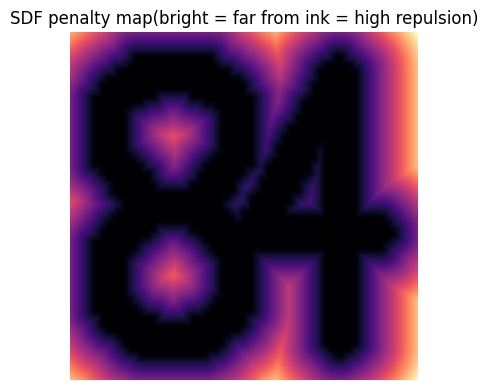

Epoch     0 | Loss 6.28620 | MSE 0.62478 | SDF 0.00000 | blur 0.07000 | active strokes: 21/42
Epoch   300 | Loss 1.04764 | MSE 0.10363 | SDF 0.00000 | blur 0.03949 | active strokes: 20/42
Epoch   600 | Loss 0.31140 | MSE 0.03024 | SDF 0.00041 | blur 0.02228 | active strokes: 22/42
Epoch   900 | Loss 0.26277 | MSE 0.02534 | SDF 0.00062 | blur 0.01257 | active strokes: 22/42
Epoch  1200 | Loss 0.34350 | MSE 0.03339 | SDF 0.00062 | blur 0.00709 | active strokes: 22/42
Epoch  1500 | Loss 0.36610 | MSE 0.03553 | SDF 0.00074 | blur 0.00400 | active strokes: 22/42


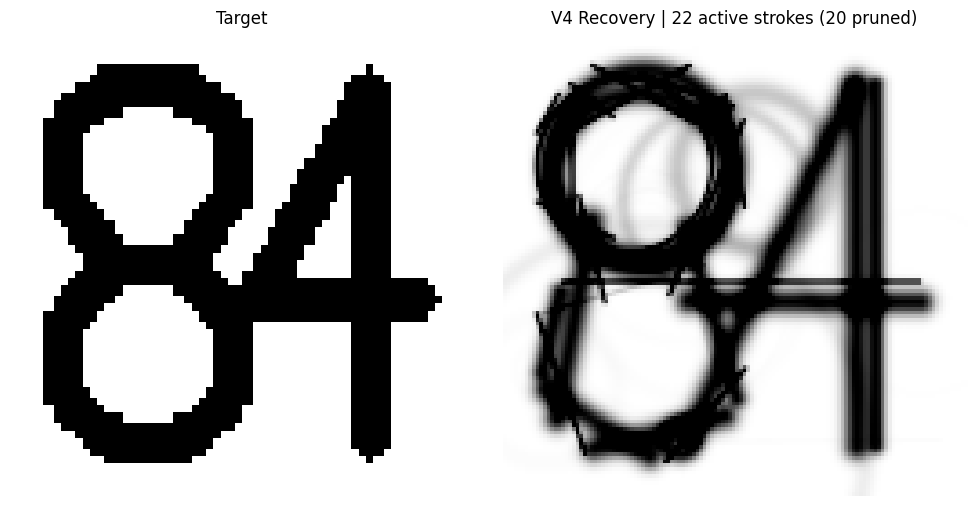

Active strokes: 22 / 42
Opacity distribution: [0.   0.   0.01 0.   0.   0.   0.01 1.   0.   0.   1.   1.   0.12 1.
 0.99 1.   0.99 1.   0.99 1.   1.   1.   1.   0.01 0.99 0.   0.   0.
 1.   0.   1.   1.   0.   0.   0.02 0.98 1.   1.   0.2  1.   0.01 0.99]
Saved 22 active strokes for sample_01799.png
Processing: sample_00476.png
  Skeleton pixels: 1471 -> 120 strokes assigned
  Detected circular blobs: 24
[sample_00476.png] 120 strokes | blur 0.070 -> 0.0040


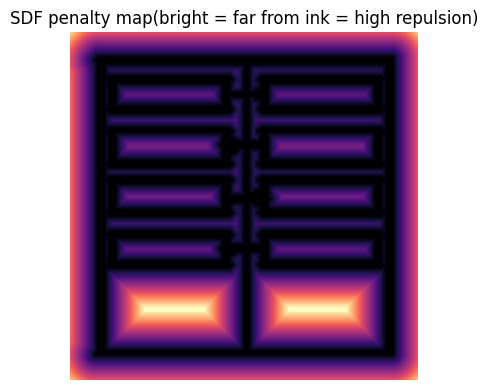

Epoch     0 | Loss 7.55447 | MSE 0.75157 | SDF 0.00000 | blur 0.07000 | active strokes: 59/120
Epoch   300 | Loss 1.51832 | MSE 0.15125 | SDF 0.00000 | blur 0.03949 | active strokes: 15/120
Epoch   600 | Loss 1.40457 | MSE 0.13973 | SDF 0.00138 | blur 0.02228 | active strokes: 17/120
Epoch   900 | Loss 1.22867 | MSE 0.12205 | SDF 0.00177 | blur 0.01257 | active strokes: 20/120
Epoch  1200 | Loss 1.10187 | MSE 0.10942 | SDF 0.00141 | blur 0.00709 | active strokes: 23/120
Epoch  1500 | Loss 1.19711 | MSE 0.11889 | SDF 0.00126 | blur 0.00400 | active strokes: 25/120


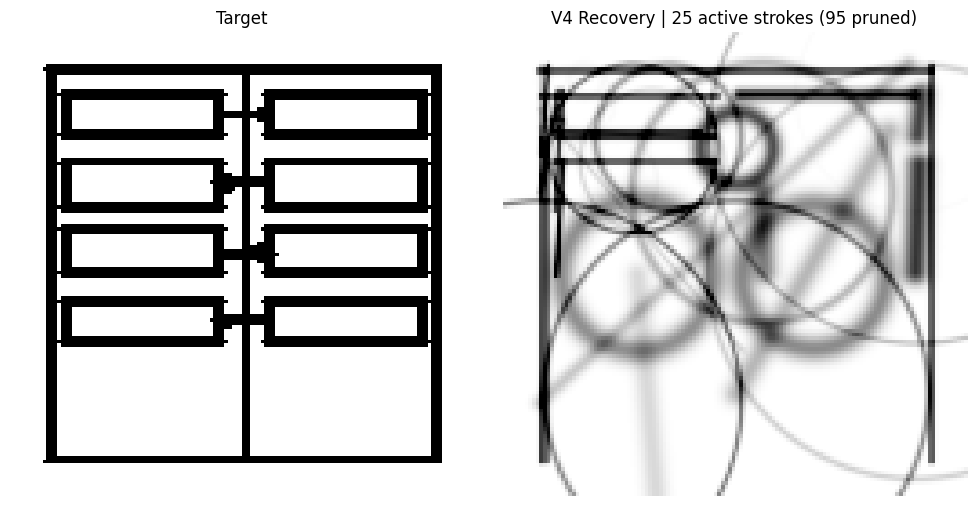

Active strokes: 25 / 120
Opacity distribution: [0.02 0.   0.1  0.01 0.99 0.   0.   0.   0.99 0.03 0.01 0.   0.   0.51
 0.01 0.04 0.   0.01 0.   0.   0.   0.92 0.   0.01 0.79 0.01 0.01 0.01
 1.   0.   0.05 0.   0.97 0.96 0.01 0.   0.01 0.   0.01 0.   0.   0.66
 0.   0.01 1.   0.   1.   0.   0.28 0.01 0.   0.02 0.   0.01 0.   0.
 0.   0.   0.   0.56 0.98 0.   0.   1.   0.   0.   0.   0.   0.01 0.03
 0.01 0.03 0.01 0.   0.   0.02 0.04 0.99 0.02 0.   0.   0.   0.02 0.01
 0.   0.   0.01 0.01 0.01 0.01 0.14 0.   0.   0.01 1.   0.01 0.   1.
 1.   1.   0.   0.99 0.   0.   1.   0.   0.01 0.   0.01 1.   1.   0.78
 0.   0.   1.   0.   0.   0.   0.   0.  ]
Saved 25 active strokes for sample_00476.png
Processing: sample_00531.png
  Skeleton pixels: 928 -> 80 strokes assigned
  Detected circular blobs: 0
[sample_00531.png] 80 strokes | blur 0.070 -> 0.0040


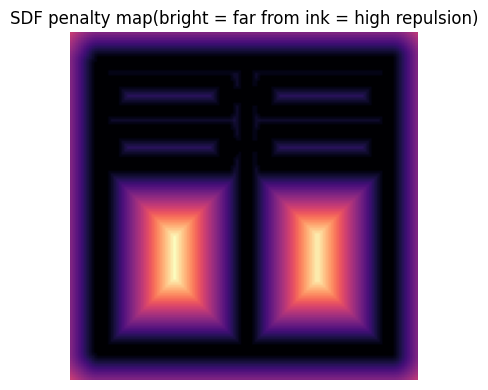

Epoch     0 | Loss 7.43016 | MSE 0.73909 | SDF 0.00000 | blur 0.07000 | active strokes: 42/80
Epoch   300 | Loss 1.64461 | MSE 0.16352 | SDF 0.00000 | blur 0.03949 | active strokes: 21/80
Epoch   600 | Loss 1.21698 | MSE 0.12065 | SDF 0.00187 | blur 0.02228 | active strokes: 22/80
Epoch   900 | Loss 0.49729 | MSE 0.04879 | SDF 0.00107 | blur 0.01257 | active strokes: 24/80
Epoch  1200 | Loss 0.43342 | MSE 0.04205 | SDF 0.00077 | blur 0.00709 | active strokes: 28/80
Epoch  1500 | Loss 0.56632 | MSE 0.05516 | SDF 0.00091 | blur 0.00400 | active strokes: 31/80


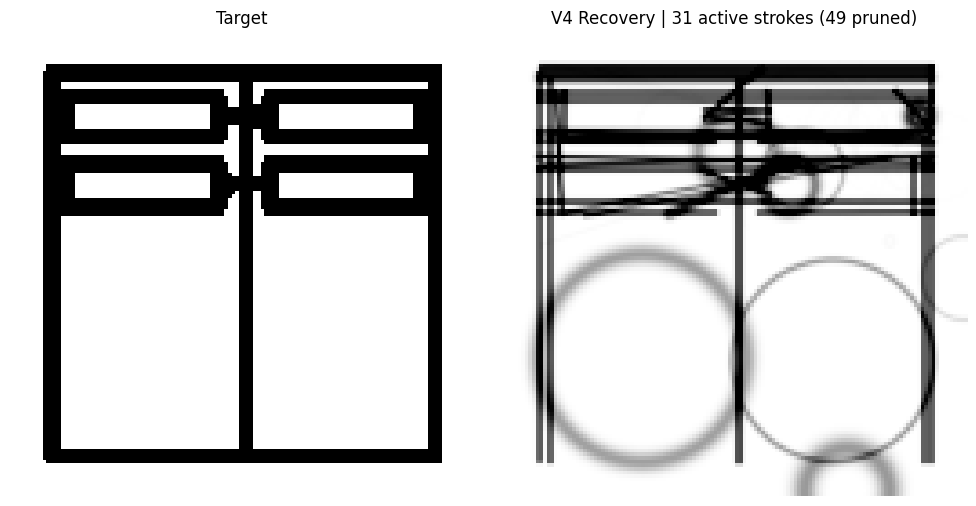

Active strokes: 31 / 80
Opacity distribution: [0.   1.   0.   0.05 1.   1.   0.01 1.   0.01 0.   0.86 1.   0.   0.
 1.   0.   1.   0.92 0.   0.01 0.89 0.   0.   1.   0.   1.   1.   0.9
 0.   0.   0.81 0.   0.   1.   0.   0.94 0.   0.   0.06 0.   1.   0.
 0.01 0.   1.   0.   0.45 0.   0.   0.   1.   0.   1.   1.   0.5  0.
 0.   1.   0.01 1.   1.   0.01 0.   0.06 0.01 1.   0.67 0.93 0.   0.17
 0.03 0.   1.   0.   0.   0.44 0.   0.   1.   0.99]
Saved 31 active strokes for sample_00531.png
Dataset saved to stroke_dataset.json (3 images)


In [7]:
run_factory()